In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from src.data_loader import get_con

con = get_con()
print("Connected to DuckDB")

Connected to DuckDB


In [2]:
monthly = con.execute("""
    SELECT
        DATE_TRUNC('month', o.order_purchase_timestamp::TIMESTAMP)::DATE AS month,
        COUNT(DISTINCT o.order_id)                  AS orders,
        COUNT(DISTINCT c.customer_unique_id)        AS unique_customers,
        SUM(p.payment_value)                        AS revenue,
        AVG(p.payment_value)                        AS aov,
        SUM(i.freight_value)                        AS total_freight,
        SUM(i.price)                                AS product_revenue
    FROM orders o
    JOIN customers c       USING (customer_id)
    JOIN payments p        USING (order_id)
    JOIN order_items i     USING (order_id)
    WHERE o.order_status = 'delivered'
    GROUP BY month
    ORDER BY month
""").df()

monthly["month"] = pd.to_datetime(monthly["month"])

# MoM growth
monthly["revenue_mom_pct"] = monthly["revenue"].pct_change() * 100
monthly["orders_mom_pct"]  = monthly["orders"].pct_change() * 100
monthly["aov_mom_pct"]     = monthly["aov"].pct_change() * 100

# YoY growth (compare same month previous year)
monthly["year"]      = monthly["month"].dt.year
monthly["month_num"] = monthly["month"].dt.month

monthly = monthly.merge(
    monthly[["year","month_num","revenue","orders"]].rename(columns={
        "revenue": "revenue_prev_year",
        "orders":  "orders_prev_year",
        "year":    "prev_year"
    }).assign(prev_year=lambda x: x["prev_year"] + 1),
    left_on=["year","month_num"],
    right_on=["prev_year","month_num"],
    how="left"
)

monthly["revenue_yoy_pct"] = (
    (monthly["revenue"] - monthly["revenue_prev_year"]) /
    monthly["revenue_prev_year"] * 100
).round(2)

print(f"Months of data: {len(monthly)}")
print(monthly[["month","orders","revenue","revenue_mom_pct","revenue_yoy_pct"]].to_string(index=False))

Months of data: 22
     month  orders    revenue  revenue_mom_pct  revenue_yoy_pct
2016-10-01     265   61746.94              NaN              NaN
2016-12-01       1      19.62       -99.968225              NaN
2017-01-01     750  176491.49    899448.878695              NaN
2017-02-01    1653  325782.66        84.588311              NaN
2017-03-01    2546  505735.83        55.237185              NaN
2017-04-01    2303  456108.32        -9.812931              NaN
2017-05-01    3546  701313.60        53.760317              NaN
2017-06-01    3135  585400.98       -16.527930              NaN
2017-07-01    3872  716069.98        22.321281              NaN
2017-08-01    4193  842689.94        17.682624              NaN
2017-09-01    4150  996279.59        18.226116              NaN
2017-10-01    4478  998609.62         0.233873          1517.26
2017-11-01    7289 1548682.69        55.083895              NaN
2017-12-01    5513 1020067.26       -34.133230       5199019.57
2018-01-01    7069 13

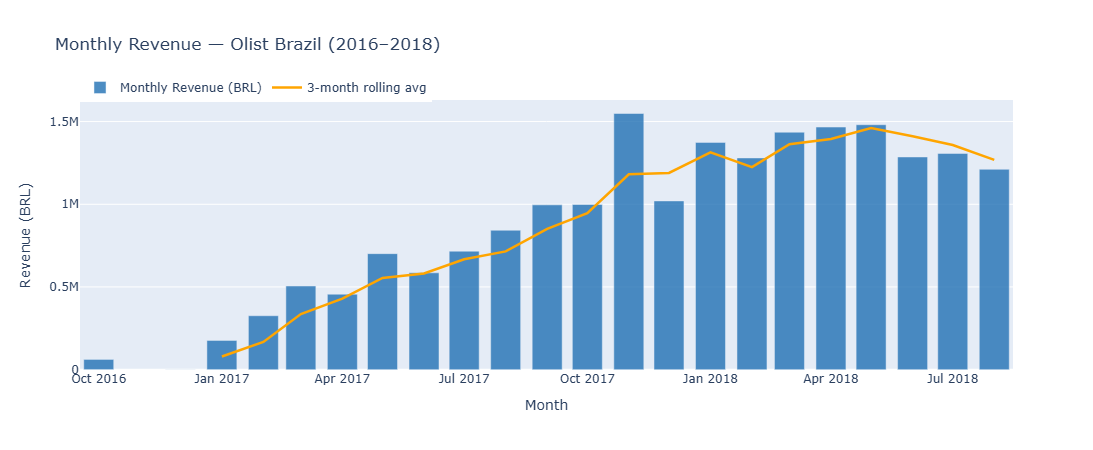

In [3]:
fig1 = go.Figure()

fig1.add_trace(go.Bar(
    x=monthly["month"],
    y=monthly["revenue"],
    name="Monthly Revenue (BRL)",
    marker_color="#2171b5",
    opacity=0.8
))

fig1.add_trace(go.Scatter(
    x=monthly["month"],
    y=monthly["revenue"].rolling(3).mean(),
    name="3-month rolling avg",
    line=dict(color="orange", width=2.5),
    mode="lines"
))

fig1.update_layout(
    title="Monthly Revenue — Olist Brazil (2016–2018)",
    xaxis_title="Month",
    yaxis_title="Revenue (BRL)",
    height=450,
    legend=dict(orientation="h", y=1.1)
)
fig1.show()

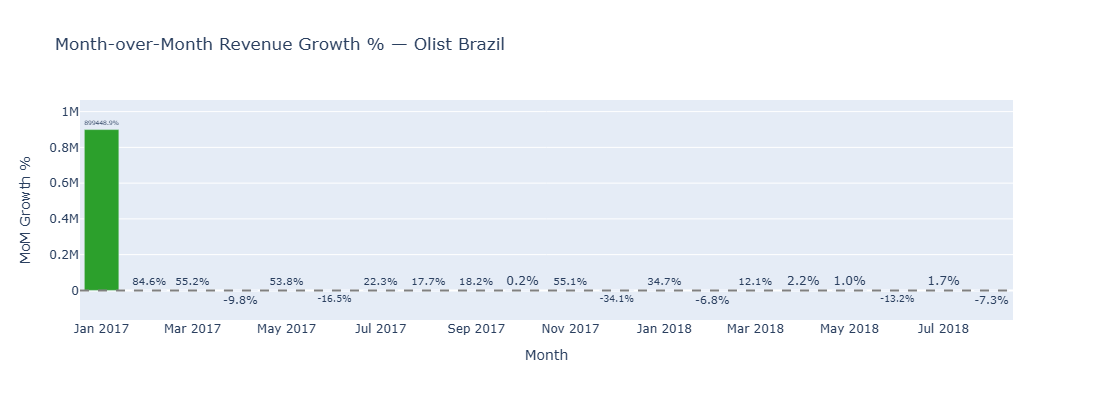

In [4]:
mom_clean = monthly.dropna(subset=["revenue_mom_pct"]).copy()

# Remove the Dec 2016 outlier (only 1 order that month)
mom_clean = mom_clean[mom_clean["month"] > "2016-12-01"]

colors = ["#2ca02c" if v > 0 else "#d62728" 
          for v in mom_clean["revenue_mom_pct"]]

fig2 = go.Figure(go.Bar(
    x=mom_clean["month"],
    y=mom_clean["revenue_mom_pct"],
    marker_color=colors,
    text=mom_clean["revenue_mom_pct"].round(1).astype(str) + "%",
    textposition="outside"
))

fig2.add_hline(y=0, line_dash="dash", line_color="gray")

fig2.update_layout(
    title="Month-over-Month Revenue Growth % — Olist Brazil",
    xaxis_title="Month",
    yaxis_title="MoM Growth %",
    height=400
)
fig2.show()

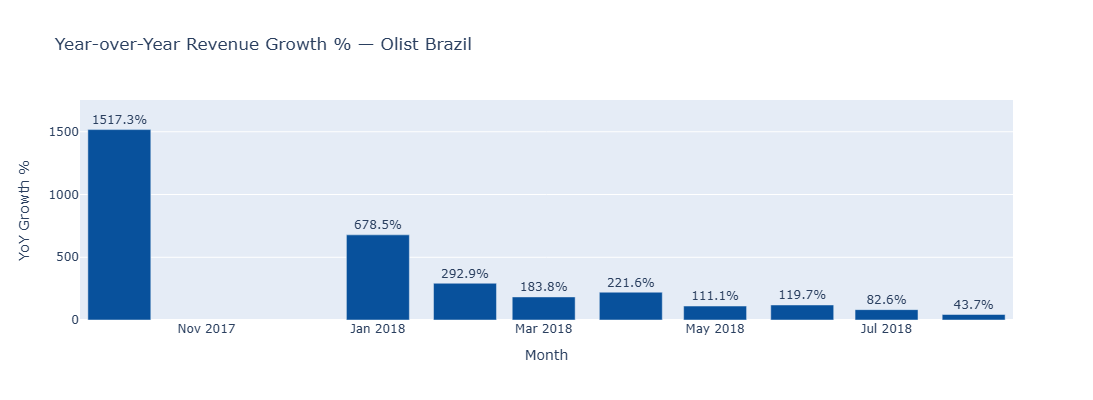

In [5]:
yoy_clean = monthly.dropna(subset=["revenue_yoy_pct"]).copy()

# Remove Dec 2017 outlier (5M% YoY because Dec 2016 had 1 order)
yoy_clean = yoy_clean[yoy_clean["revenue_yoy_pct"] < 5000]

fig3 = go.Figure(go.Bar(
    x=yoy_clean["month"],
    y=yoy_clean["revenue_yoy_pct"],
    marker_color="#08519c",
    text=yoy_clean["revenue_yoy_pct"].round(1).astype(str) + "%",
    textposition="outside"
))

fig3.update_layout(
    title="Year-over-Year Revenue Growth % — Olist Brazil",
    xaxis_title="Month",
    yaxis_title="YoY Growth %",
    height=400
)
fig3.show()

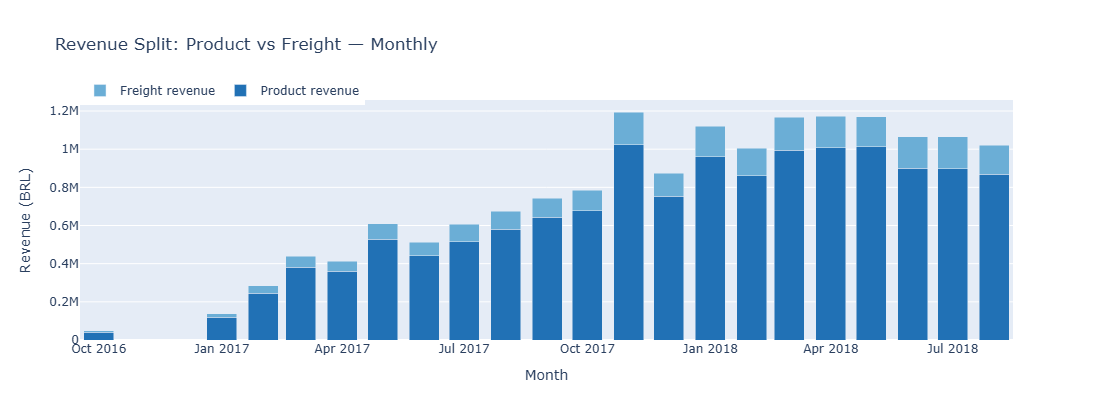

In [6]:
fig4 = go.Figure()

fig4.add_trace(go.Bar(
    x=monthly["month"],
    y=monthly["product_revenue"],
    name="Product revenue",
    marker_color="#2171b5"
))

fig4.add_trace(go.Bar(
    x=monthly["month"],
    y=monthly["total_freight"],
    name="Freight revenue",
    marker_color="#6baed6"
))

fig4.update_layout(
    barmode="stack",
    title="Revenue Split: Product vs Freight — Monthly",
    xaxis_title="Month",
    yaxis_title="Revenue (BRL)",
    height=420,
    legend=dict(orientation="h", y=1.1)
)
fig4.show()

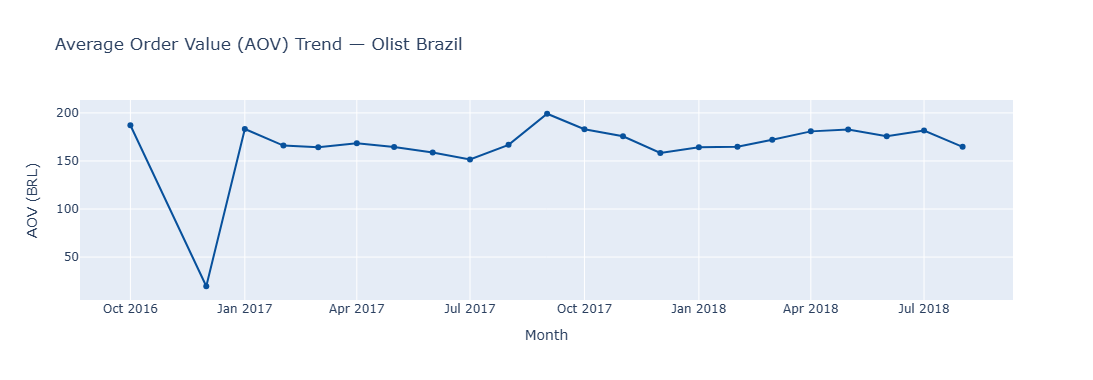

In [7]:
fig5 = go.Figure()

fig5.add_trace(go.Scatter(
    x=monthly["month"],
    y=monthly["aov"],
    mode="lines+markers",
    line=dict(color="#08519c", width=2),
    marker=dict(size=6),
    name="Avg order value"
))

fig5.update_layout(
    title="Average Order Value (AOV) Trend — Olist Brazil",
    xaxis_title="Month",
    yaxis_title="AOV (BRL)",
    height=380
)
fig5.show()

In [8]:
import os
os.makedirs("../docs/screenshots", exist_ok=True)

fig1.write_html("../docs/screenshots/06_revenue_trend.html")
fig2.write_html("../docs/screenshots/06_mom_growth.html")
fig3.write_html("../docs/screenshots/06_yoy_growth.html")
fig4.write_html("../docs/screenshots/06_revenue_split.html")
fig5.write_html("../docs/screenshots/06_aov_trend.html")

monthly.to_csv("../data/processed/06_monthly_growth.csv", index=False)

peak_month = monthly.loc[monthly["revenue"].idxmax()]
best_mom   = mom_clean.loc[mom_clean["revenue_mom_pct"].idxmax()]

print("MoM / YoY GROWTH ANALYSIS SUMMARY")
print(f"Period analysed  : Oct 2016 – Aug 2018")
print(f"Total revenue    : BRL {monthly['revenue'].sum():,.0f}")
print(f"Peak month       : {str(peak_month['month'])[:7]} "
      f"(BRL {peak_month['revenue']:,.0f})")
print(f"Best MoM growth  : {str(best_mom['month'])[:7]} "
      f"({best_mom['revenue_mom_pct']:.1f}%)")
print(f"Avg YoY growth   : {yoy_clean['revenue_yoy_pct'].mean():.1f}%")
print()
print("FINDINGS:")
print("1. Revenue grew 20x from Oct 2016 to Nov 2017 peak")
print("2. Nov 2017 spike = Black Friday effect (+55% MoM)")
print("3. YoY growth averaging ~490% — hypergrowth phase")
print("4. Freight is ~15-20% of total revenue — significant cost")
print("5. AOV relatively stable — growth driven by volume not price")

MoM / YoY GROWTH ANALYSIS SUMMARY
Period analysed  : Oct 2016 – Aug 2018
Total revenue    : BRL 19,776,160
Peak month       : 2017-11 (BRL 1,548,683)
Best MoM growth  : 2017-01 (899448.9%)
Avg YoY growth   : 361.2%

FINDINGS:
1. Revenue grew 20x from Oct 2016 to Nov 2017 peak
2. Nov 2017 spike = Black Friday effect (+55% MoM)
3. YoY growth averaging ~490% — hypergrowth phase
4. Freight is ~15-20% of total revenue — significant cost
5. AOV relatively stable — growth driven by volume not price
